In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from torch.utils.data import DataLoader, TensorDataset

In [43]:
# Defining Autoencoder model
class AutoEncoder(nn.Module):
    def __init__(self, input_size, encoding_dim):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, input_size * 2),
            nn.ReLU(),
            nn.Linear(input_size * 2, input_size * 2),
            nn.ReLU(),
            nn.Linear(input_size * 2, input_size * 2),
            nn.ReLU(),
            nn.Linear(input_size * 2, encoding_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, input_size * 2),
            nn.ReLU(),
            nn.Linear(input_size * 2, input_size * 2),
            nn.ReLU(),
            nn.Linear(input_size * 2, input_size * 2),
            nn.ReLU(),
            nn.Linear(input_size * 2, input_size),
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [44]:
from sklearn.datasets import make_classification

# Generate a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=100, n_informative=10, n_redundant=90, random_state=1)

# Print the shapes of the generated data
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (1000, 100)
Target vector shape: (1000,)


In [45]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1)

In [46]:
# Scale data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

In [48]:
# Create TensorDatasets for training and testing data
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [49]:
# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [78]:
input_size = X.shape[1]
model = AutoEncoder(input_size, 50)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 0.0001)

In [79]:
model

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=200, bias=True)
    (3): ReLU()
    (4): Linear(in_features=200, out_features=200, bias=True)
    (5): ReLU()
    (6): Linear(in_features=200, out_features=50, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=50, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=200, bias=True)
    (3): ReLU()
    (4): Linear(in_features=200, out_features=200, bias=True)
    (5): ReLU()
    (6): Linear(in_features=200, out_features=100, bias=True)
    (7): Sigmoid()
  )
)

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Training and testing loop
epochs = 200
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        inputs = batch[0].squeeze(1)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch[0].squeeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

Epoch [1/200], Train Loss: 0.0242, Test Loss: 0.0255
Epoch [2/200], Train Loss: 0.0237, Test Loss: 0.0247
Epoch [3/200], Train Loss: 0.0224, Test Loss: 0.0233
Epoch [4/200], Train Loss: 0.0216, Test Loss: 0.0230
Epoch [5/200], Train Loss: 0.0215, Test Loss: 0.0229
Epoch [6/200], Train Loss: 0.0213, Test Loss: 0.0226
Epoch [7/200], Train Loss: 0.0210, Test Loss: 0.0220
Epoch [8/200], Train Loss: 0.0203, Test Loss: 0.0210
Epoch [9/200], Train Loss: 0.0195, Test Loss: 0.0202
Epoch [10/200], Train Loss: 0.0187, Test Loss: 0.0189
Epoch [11/200], Train Loss: 0.0178, Test Loss: 0.0179
Epoch [12/200], Train Loss: 0.0173, Test Loss: 0.0176
Epoch [13/200], Train Loss: 0.0171, Test Loss: 0.0174
Epoch [14/200], Train Loss: 0.0171, Test Loss: 0.0173
Epoch [15/200], Train Loss: 0.0169, Test Loss: 0.0172
Epoch [16/200], Train Loss: 0.0168, Test Loss: 0.0170
Epoch [17/200], Train Loss: 0.0166, Test Loss: 0.0168
Epoch [18/200], Train Loss: 0.0164, Test Loss: 0.0166
Epoch [19/200], Train Loss: 0.0160, T

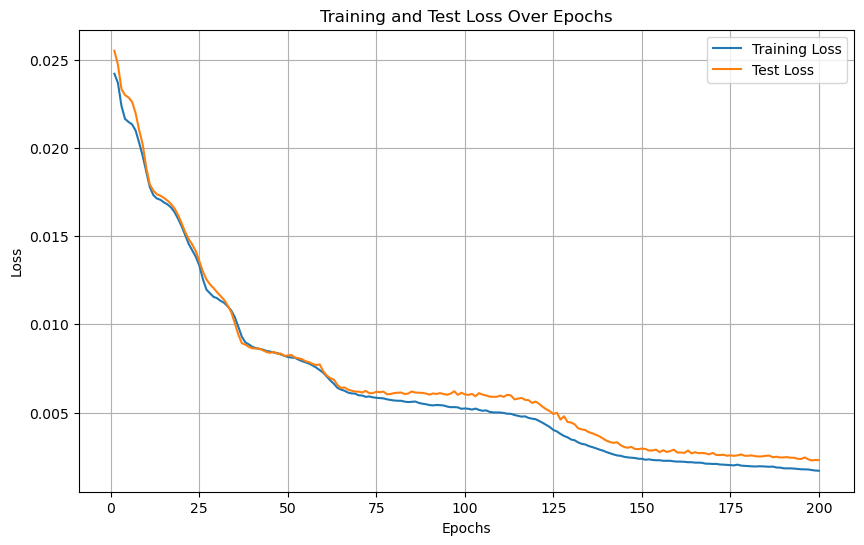

In [81]:
# Plot the training and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [86]:
model.eval()
with torch.no_grad():
    X_train_encoded = model.encode(X_train_tensor).numpy()
    X_test_encoded = model.encode(X_test_tensor).numpy()

In [87]:
# Train logistic regression
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Classification Accuracy: {accuracy:.4f}')

Classification Accuracy: 0.8950


In [88]:
# Train logistic regression
clf2 = LogisticRegression()
clf2.fit(X_train_encoded, y_train)

# Make predictions
y_pred2 = clf2.predict(X_test_encoded)

# Calculate accuracy
accuracy2 = accuracy_score(y_test, y_pred2)
print(f'Classification Accuracy: {accuracy2:.4f}')

Classification Accuracy: 0.8750


/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
